# Phase 1 — Data Exploration & Baseline Understanding

**Paper:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification  
**Reference:** Milani, S. — University of Padova

---

## What this notebook does

1. Loads the IMU test dataset (accelerometer + gyroscope signals)
2. Explores the data structure, shapes, and label distribution
3. Visualizes raw gait signals for individual subjects
4. Verifies the continual learning task split used in the paper (Table II)
5. Computes per-subject signal statistics as a sanity check

## Dataset structure

Each row in the signal files is one **128-sample gait window** from a smartphone IMU.  
We have 6 channels: `acc_x, acc_y, acc_z, gyr_x, gyr_y, gyr_z`.  
Labels (`y_test.txt`) are **subject IDs** ranging from 1 to 118.

| File | Description |
|---|---|
| `test_acc_x/y/z.txt` | Accelerometer axes (m/s²) |
| `test_gyr_x/y/z.txt` | Gyroscope axes (rad/s) |
| `y_test.txt` | Subject ID labels |

---

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set a clean plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load the data

Update `DATA_DIR` to point to the folder containing the `.txt` files.

In [2]:
# ── Configuration — edit this path to match your setup ───────────────────────
DATA_DIR = '../Data/Dataset_1/train/'   # <-- change to your local path if needed

# ── Load signal files ─────────────────────────────────────────────────────────
def load_signal(path):
    """Load a whitespace-separated signal file. Each row = one 128-sample window."""
    return np.loadtxt(path)  # shape: (N_samples, 128)

acc_x = load_signal(DATA_DIR + 'Inertial_Signals/train_acc_x.txt')
acc_y = load_signal(DATA_DIR + 'Inertial_Signals/train_acc_y.txt')
acc_z = load_signal(DATA_DIR + 'Inertial_Signals/train_acc_z.txt')
gyr_x = load_signal(DATA_DIR + 'Inertial_Signals/train_gyr_x.txt')
gyr_y = load_signal(DATA_DIR + 'Inertial_Signals/train_gyr_y.txt')
gyr_z = load_signal(DATA_DIR + 'Inertial_Signals/train_gyr_z.txt')
y     = np.loadtxt(DATA_DIR + 'y_train.txt', dtype=int)

# Stack into a single array: shape (N_samples, 6_channels, 128_timesteps)
X = np.stack([acc_x, acc_y, acc_z, gyr_x, gyr_y, gyr_z], axis=1)

CHANNEL_NAMES = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']

print(f'X shape : {X.shape}  →  (samples, channels, timesteps)')
print(f'y shape : {y.shape}')
print(f'Label range: {y.min()} – {y.max()}')
print(f'Unique subjects: {len(np.unique(y))}')

X shape : (33104, 6, 128)  →  (samples, channels, timesteps)
y shape : (33104,)
Label range: 1 – 118
Unique subjects: 118


## 2. Basic statistics

In [3]:
# ── Per-channel statistics ────────────────────────────────────────────────────
stats = pd.DataFrame({
    'channel': CHANNEL_NAMES,
    'mean':    X.mean(axis=(0, 2)),
    'std':     X.std(axis=(0, 2)),
    'min':     X.min(axis=(0, 2)),
    'max':     X.max(axis=(0, 2)),
})
print('── Global channel statistics ──')
print(stats.to_string(index=False, float_format='{:.4f}'.format))

# ── Samples per subject ───────────────────────────────────────────────────────
counts = Counter(y)
count_vals = list(counts.values())
print(f'\n── Samples per subject ──')
print(f'  Min: {min(count_vals)}   Max: {max(count_vals)}   Mean: {np.mean(count_vals):.1f}')

── Global channel statistics ──
channel    mean    std      min     max
  acc_x  0.4904 4.9742 -62.8792 65.0840
  acc_y -5.9197 8.1408 -76.3655 59.0506
  acc_z -0.4948 4.4256 -69.0584 69.3169
  gyr_x  0.0017 0.6672 -74.2149 51.4069
  gyr_y -0.0001 0.9471 -70.2483 69.6708
  gyr_z  0.0009 0.4261 -66.3815 72.9703

── Samples per subject ──
  Min: 42   Max: 575   Mean: 280.5


## 3. Class distribution

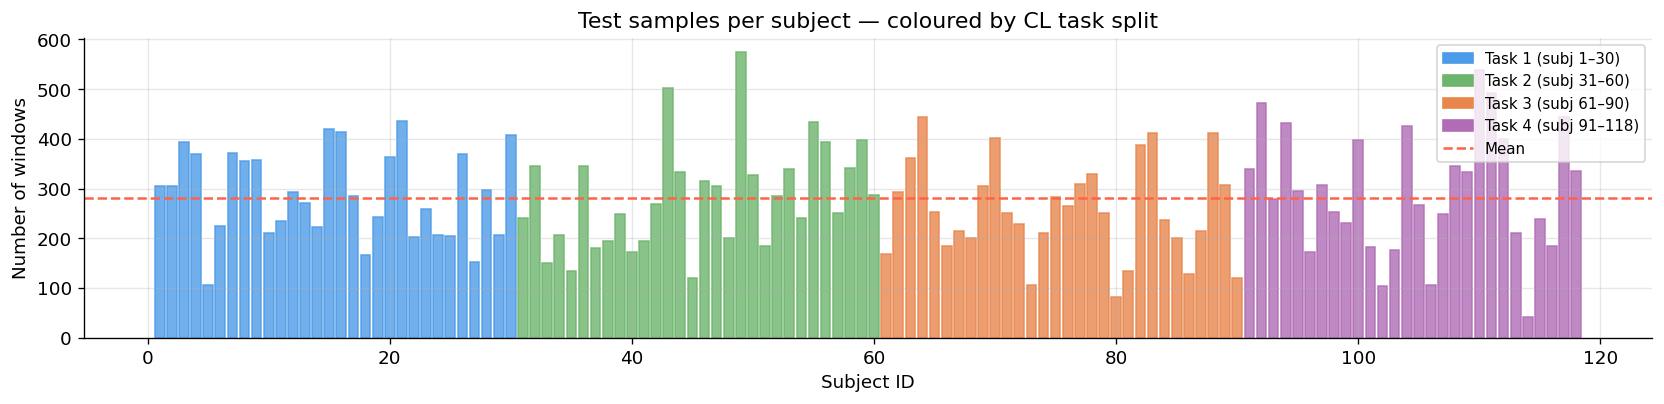

Saved: fig_class_distribution.png


In [5]:
# ── Plot: samples per subject ID ─────────────────────────────────────────────
subjects_sorted = sorted(counts.keys())
sample_counts   = [counts[s] for s in subjects_sorted]

fig, ax = plt.subplots(figsize=(14, 3.5))
bars = ax.bar(subjects_sorted, sample_counts, width=0.8, color='steelblue', alpha=0.75)
ax.axhline(np.mean(sample_counts), color='tomato', linewidth=1.5,
           linestyle='--', label=f'Mean = {np.mean(sample_counts):.1f}')

# Colour-code by task
task_colors = ['#4C9BE8', '#6DB56D', '#E8864C', '#B06DB5']
task_bounds = [(1, 30), (31, 60), (61, 90), (91, 118)]
for i, (lo, hi) in enumerate(task_bounds):
    for b, s in zip(bars, subjects_sorted):
        if lo <= s <= hi:
            b.set_color(task_colors[i])
            b.set_alpha(0.8)

# Add task label patches to legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=f'Task {i+1} (subj {lo}–{hi})')
                  for i, (c, (lo, hi)) in enumerate(zip(task_colors, task_bounds))]
legend_patches.append(plt.Line2D([0],[0], color='tomato', linestyle='--', label='Mean'))
ax.legend(handles=legend_patches, loc='upper right', fontsize=9)

ax.set_xlabel('Subject ID')
ax.set_ylabel('Number of windows')
ax.set_title('Test samples per subject — coloured by CL task split')
plt.tight_layout()
plt.savefig('../Plots/fig_class_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: fig_class_distribution.png')

## 4. Visualize raw gait signals for a single subject

This shows what the 128-sample windows look like for one individual across all 6 IMU channels.

Subject 1 has 305 windows in the test set.


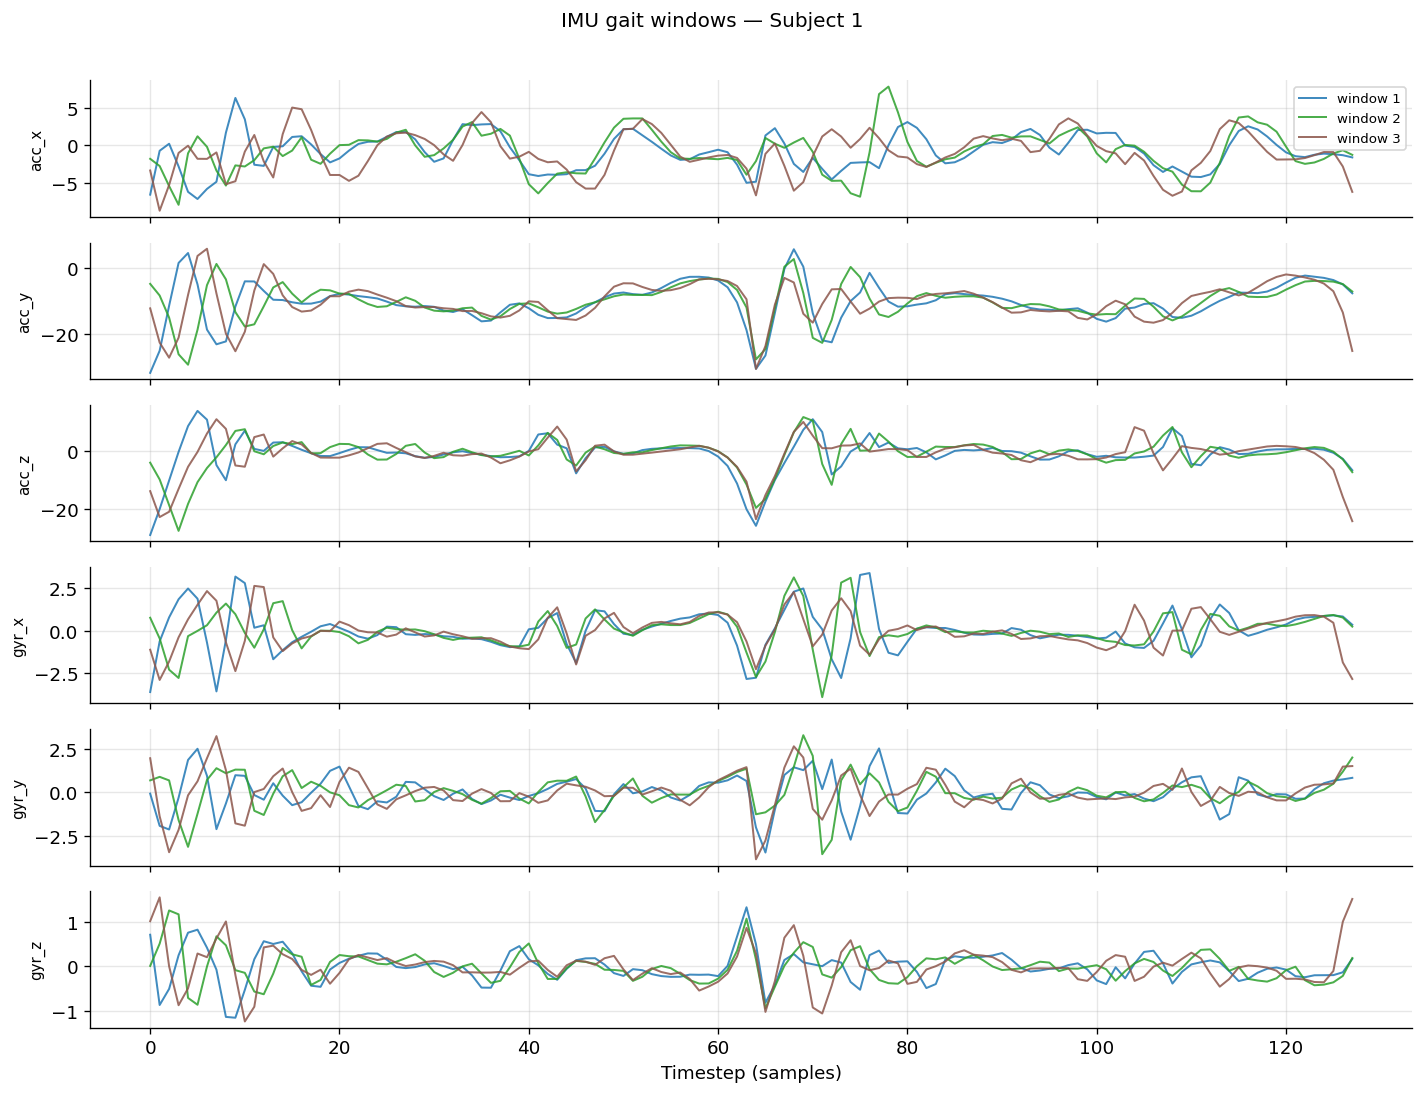

Saved: fig_signal_subject1.png


In [6]:
# ── Pick a subject and a few of their windows ─────────────────────────────────
SUBJECT_ID = 1       # <-- change to any subject ID you want to inspect
N_WINDOWS  = 3       # how many windows to overlay

idx = np.where(y == SUBJECT_ID)[0]
print(f'Subject {SUBJECT_ID} has {len(idx)} windows in the test set.')

# Select a few windows
selected = idx[:N_WINDOWS]
t = np.arange(128)

fig, axes = plt.subplots(6, 1, figsize=(12, 9), sharex=True)
colors = plt.cm.tab10(np.linspace(0, 0.5, N_WINDOWS))

for ch_idx, (ax, ch_name) in enumerate(zip(axes, CHANNEL_NAMES)):
    for win_i, (win_idx, col) in enumerate(zip(selected, colors)):
        ax.plot(t, X[win_idx, ch_idx, :], color=col, alpha=0.85,
                linewidth=1.2, label=f'window {win_i+1}')
    ax.set_ylabel(ch_name, fontsize=9)
    if ch_idx == 0:
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Timestep (samples)')
fig.suptitle(f'IMU gait windows — Subject {SUBJECT_ID}', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'../Plots/fig_signal_subject{SUBJECT_ID}.png', bbox_inches='tight')
plt.show()
print(f'Saved: fig_signal_subject{SUBJECT_ID}.png')

## 5. Compare gait patterns between two subjects

This helps build intuition for *why* gait identification works: different people walk differently.

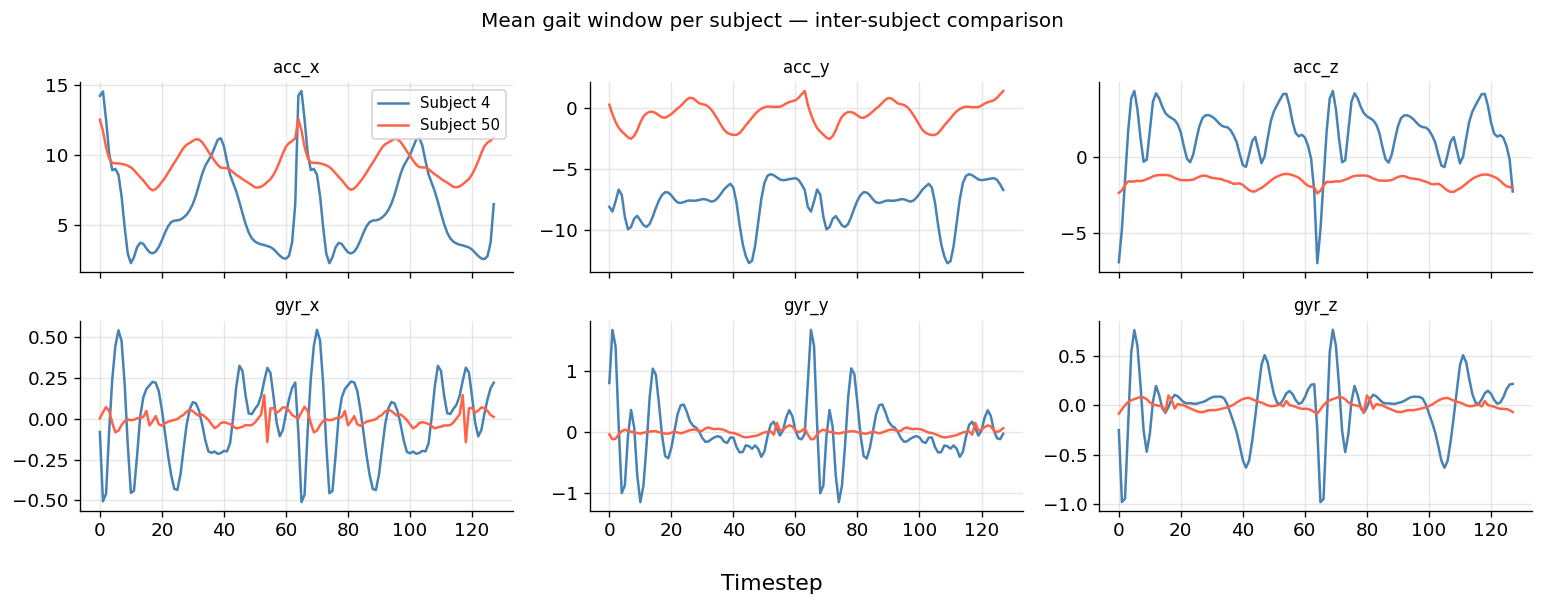

Saved: fig_intersubject_comparison.png


In [8]:
SUBJ_A = 4
SUBJ_B = 50

def mean_window(subject_id):
    """Return the mean signal window for a subject across all their windows."""
    idx = np.where(y == subject_id)[0]
    return X[idx].mean(axis=0)  # shape: (6, 128)

mean_a = mean_window(SUBJ_A)
mean_b = mean_window(SUBJ_B)

fig, axes = plt.subplots(2, 3, figsize=(13, 5), sharex=True)
axes = axes.flatten()

for ch_idx, (ax, ch_name) in enumerate(zip(axes, CHANNEL_NAMES)):
    ax.plot(mean_a[ch_idx], color='steelblue',  linewidth=1.5, label=f'Subject {SUBJ_A}')
    ax.plot(mean_b[ch_idx], color='tomato',     linewidth=1.5, label=f'Subject {SUBJ_B}')
    ax.set_title(ch_name, fontsize=10)
    if ch_idx == 0:
        ax.legend(fontsize=9)

fig.supxlabel('Timestep')
fig.suptitle('Mean gait window per subject — inter-subject comparison', fontsize=12)
plt.tight_layout()
plt.savefig('../Plots/fig_intersubject_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: fig_intersubject_comparison.png')

## 6. Continual Learning task split (Table II of the paper)

The paper divides 119 subjects across 4 tasks:  
`Task 1: 0–29`, `Task 2: 30–59`, `Task 3: 60–89`, `Task 4: 90–118`

Note: in the paper subjects are 0-indexed; here labels run 1–118, so we adjust.

In [9]:
# ── Define the 4-task split ───────────────────────────────────────────────────
# Paper uses 0-indexed subjects. Our labels are 1-indexed — adjust accordingly.
TASK_SPLITS = {
    'Task 1': (1,   30),
    'Task 2': (31,  60),
    'Task 3': (61,  90),
    'Task 4': (91, 118),
}

print('── CL Task split summary ──')
print(f'{"Task":<10} {"Subj range":<15} {"Test windows":<15} {"Unique subj"}')
print('-' * 55)

task_masks = {}  # store boolean masks for later use
for task_name, (lo, hi) in TASK_SPLITS.items():
    mask = (y >= lo) & (y <= hi)
    task_masks[task_name] = mask
    n_win  = mask.sum()
    n_subj = len(np.unique(y[mask]))
    print(f'{task_name:<10} {lo}–{hi:<12} {n_win:<15} {n_subj}')

print(f'\nTotal test windows: {len(y)}')

── CL Task split summary ──
Task       Subj range      Test windows    Unique subj
-------------------------------------------------------
Task 1     1–30           8643            30
Task 2     31–60           8518            30
Task 3     61–90           7693            30
Task 4     91–118          8250            28

Total test windows: 33104


## 7. Signal magnitude and frequency analysis

Look at the power spectrum of gait signals — gait has a characteristic ~2 Hz fundamental frequency.

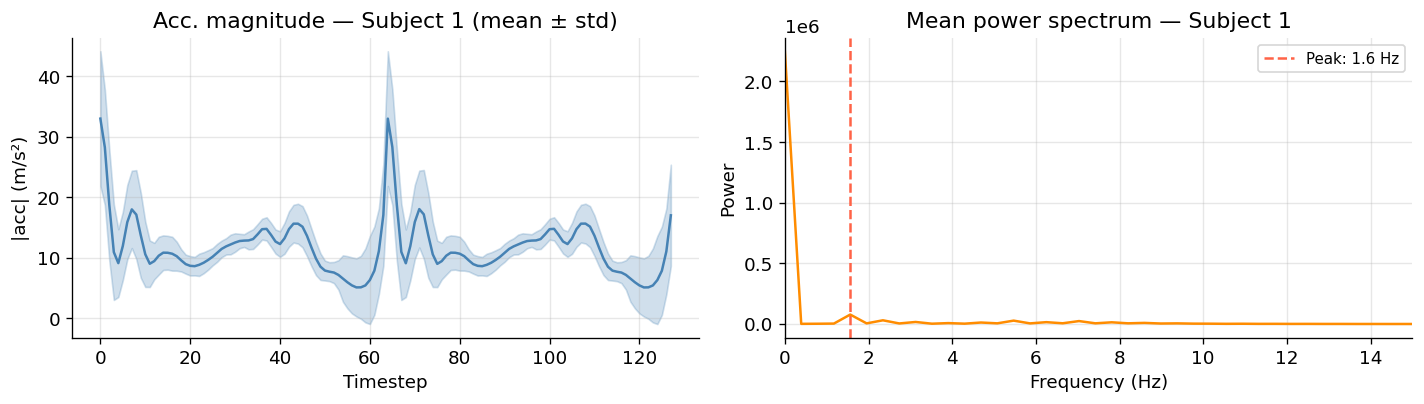

Dominant gait frequency for subject 1: 1.56 Hz
Saved: fig_signal_frequency.png


In [10]:
# ── FFT of accelerometer norm for one subject ─────────────────────────────────
SAMPLING_RATE = 50  # Hz — typical for smartphone gait datasets (Zou et al. 2020)
SUBJECT_FFT   = 1

idx = np.where(y == SUBJECT_FFT)[0]
# Compute accelerometer norm for all windows of this subject
acc_norm = np.sqrt(
    X[idx, 0, :]**2 + X[idx, 1, :]**2 + X[idx, 2, :]**2
)  # shape: (n_windows, 128)

# Average power spectrum
freqs  = np.fft.rfftfreq(128, d=1/SAMPLING_RATE)
spectra = np.abs(np.fft.rfft(acc_norm, axis=1))**2
mean_spectrum = spectra.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

# Left: time domain (mean ± std)
mean_sig = acc_norm.mean(axis=0)
std_sig  = acc_norm.std(axis=0)
axes[0].plot(np.arange(128), mean_sig, color='steelblue', linewidth=1.5)
axes[0].fill_between(np.arange(128), mean_sig - std_sig, mean_sig + std_sig,
                     alpha=0.25, color='steelblue')
axes[0].set_xlabel('Timestep')
axes[0].set_ylabel('|acc| (m/s²)')
axes[0].set_title(f'Acc. magnitude — Subject {SUBJECT_FFT} (mean ± std)')

# Right: frequency domain
axes[1].plot(freqs, mean_spectrum, color='darkorange', linewidth=1.5)
axes[1].set_xlim(0, 15)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Power')
axes[1].set_title(f'Mean power spectrum — Subject {SUBJECT_FFT}')
# Mark dominant gait frequency
peak_freq = freqs[np.argmax(mean_spectrum[1:]) + 1]
axes[1].axvline(peak_freq, color='tomato', linestyle='--',
                label=f'Peak: {peak_freq:.1f} Hz')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../Plots/fig_signal_frequency.png', bbox_inches='tight')
plt.show()
print(f'Dominant gait frequency for subject {SUBJECT_FFT}: {peak_freq:.2f} Hz')
print('Saved: fig_signal_frequency.png')

## 8. Per-task signal statistics

Check whether subjects in different tasks have noticeably different signal characteristics — this would affect how hard the CL problem is.

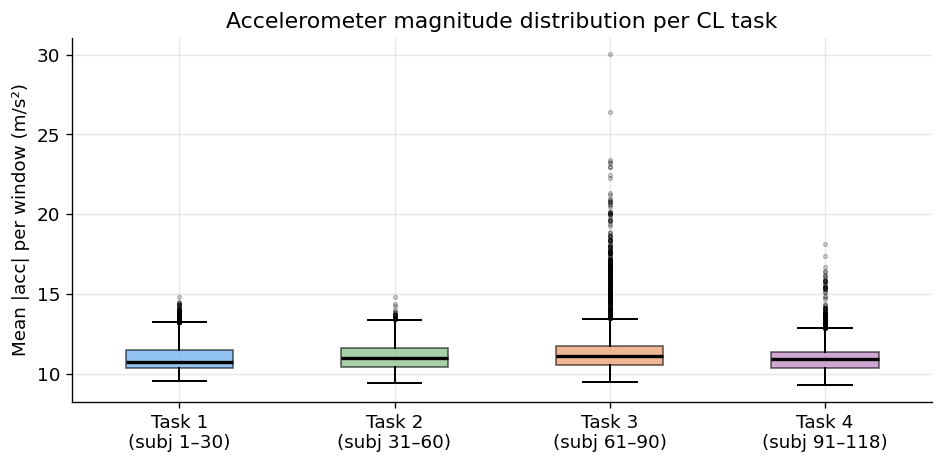

Saved: fig_pertask_stats.png


In [15]:
# ── Accelerometer norm mean/std per task ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

task_colors_list = ['#4C9BE8', '#6DB56D', '#E8864C', '#B06DB5']
positions = []

for i, (task_name, mask) in enumerate(task_masks.items()):
    X_task = X[mask]
    acc_norm_task = np.sqrt(X_task[:,0,:]**2 + X_task[:,1,:]**2 + X_task[:,2,:]**2)
    rms_per_window = acc_norm_task.mean(axis=1)  # mean magnitude per window
    bp = ax.boxplot(rms_per_window, positions=[i+1], widths=0.5,
                    patch_artist=True,
                    boxprops=dict(facecolor=task_colors_list[i], alpha=0.6),
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['Task 1\n(subj 1–30)', 'Task 2\n(subj 31–60)',
                    'Task 3\n(subj 61–90)', 'Task 4\n(subj 91–118)'])
ax.set_ylabel('Mean |acc| per window (m/s²)')
ax.set_title('Accelerometer magnitude distribution per CL task')
plt.tight_layout()
plt.savefig('../Plots/fig_pertask_stats.png', bbox_inches='tight')
plt.show()
print('Saved: fig_pertask_stats.png')